# Master of Data Science at UBCO — DATA589
# Lab 3 — Vision Transformers: Classification, Detection & Segmentation

**Course:** DATA589 Applied Computer Vision and Deep Learning  
**Level:** Master's  
**Topic:** ViT-based models from Hugging Face for image classification, object detection, and semantic segmentation  
**Estimated time:** 3–4 hours  
**Recommended platform:** **Google Colab (T4 GPU)**

---

## Why this lab?

**Lecture 3** covered the CNN pipeline — convolution, ReLU, pooling — and showed how CNNs learn local features.
You explored object detection (R-CNN → Faster R-CNN → YOLO) and saw semantic segmentation as pixel-level prediction.

**Lecture 4** revealed a fundamental limitation:

> *CNNs model only local neighborhoods. Two pixels far apart in an image never interact directly,
> no matter how many neurons are in between.*

The solution: **Attention + Vision Transformers (ViT)**. In ViT:

| Component | Role |
|-----------|------|
| **Patches** | Image is split into N×N fixed-size tiles — each becomes a *token* |
| **Patch embedding** | Each tile is linearly projected to a D-dim vector |
| **Positional encoding** | Each token gets a spatial coordinate injected |
| **Self-attention** | Every token attends to every other — global context at each layer |
| **[CLS] token** | A special learnable token that aggregates the whole-image summary |
| **Multi-head attention** | Multiple parallel heads learn different relationship patterns |

This lab uses **pre-trained ViT-based models** directly from **Hugging Face Hub** to perform
all three core CV tasks you have studied:

| Task | Model | Architecture |
|------|-------|-------------|
| Image Classification | `google/vit-base-patch16-224` | Pure ViT |
| Object Detection | `facebook/detr-resnet-50` | ResNet backbone + Transformer encoder/decoder |
| Semantic Segmentation | `nvidia/segformer-b0-finetuned-ade-512-512` | Hierarchical ViT |

---

## Running this notebook in Google Colab

1. Upload this notebook to **Google Colab**.
2. Go to **Runtime → Change runtime type → T4 GPU**.
3. Run cells **from top to bottom** in order.
4. The install cell takes ~1–2 minutes on first run.

---

## Submission Instructions

Submit:
1. Your completed `.ipynb` with **all output cells visible**.
2. Written answers in every markdown cell that requests one.

## Rules

- Discuss concepts with classmates freely.
- AI assistants may help with debugging and clarification.
- You may **not** use AI to complete the lab for you.
- Your final notebook must reflect **your own understanding and work**.


## Learning Outcomes

By the end of this lab you will be able to:

**Architecture (Lectures 3 & 4 reinforcement):**
- Explain the CNN locality limitation and how ViT overcomes it with self-attention.
- Describe how patches, positional encodings, and the CLS token work together in ViT.
- Interpret multi-head attention maps on real images and connect them to lecture theory.

**Practical Hugging Face skills:**
- Load any Hugging Face vision model with its matching `ImageProcessor`.
- Pre-process images and run inference using the unified `transformers` API.
- Post-process logits into class predictions, bounding boxes, and segmentation masks.

**Core CV tasks:**
- Run image classification and visualise confidence scores.
- Run DETR object detection and draw labelled bounding boxes.
- Run SegFormer semantic segmentation and overlay a colour mask.
- Compute IoU between bounding boxes (reinforcing Lab 2 concepts).
- Visualise ViT attention weights and connect them to Lecture 4 theory.


---

# PART A — Setup

## A.0 — Install Dependencies

> On **Google Colab** these take about 1–2 minutes on first run.
> Restart the runtime if prompted after installation.


In [ ]:
# Run once — restart runtime if Colab asks you to
!pip install -q "transformers>=4.40" timm accelerate pillow


In [ ]:
import os
import math
import warnings
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from PIL import Image

import torch
import torch.nn.functional as F

from transformers import (
    ViTForImageClassification,
    ViTImageProcessor,
    DetrForObjectDetection,
    DetrImageProcessor,
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
)

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda") # Google Colab GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps") # Mac GPU
else:
    device = torch.device("cpu") # CPU

print(f"Device  : {device}")
print(f"PyTorch : {torch.__version__}")
if device.type == "cpu":
    print("\n⚠  No GPU detected. Go to Runtime → Change runtime type → T4 GPU.")


Device  : cpu
PyTorch : 2.10.0+cpu

⚠  No GPU detected. Go to Runtime → Change runtime type → T4 GPU.


## A.1 — Helper Utilities

The cell below defines convenience functions used throughout the lab.
Read through them — they are short and instructive.


In [ ]:
def download_image(url: str, path: str, fallback_urls: list = None) -> Image.Image:
    "Download an image with browser-like headers. Tries fallbacks automatically."
    import importlib
    urls_to_try = [url] + (fallback_urls or [])
    last_error  = None

    for attempt_url in urls_to_try:
        try:
            if importlib.util.find_spec("requests") is not None:
                import requests as _req
                resp = _req.get(
                    attempt_url,
                    headers={"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36"},
                    timeout=15,
                    stream=True,
                )
                resp.raise_for_status()
                with open(path, "wb") as f:
                    for chunk in resp.iter_content(8192):
                        f.write(chunk)
            else:
                req = urllib.request.Request(
                    attempt_url,
                    headers={"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36"},
                )
                with urllib.request.urlopen(req, timeout=15) as r:
                    with open(path, "wb") as f:
                        f.write(r.read())
            return Image.open(path).convert("RGB")
        except Exception as e:
            print(f"  ↳ {type(e).__name__}: {attempt_url[:70]}")
            last_error = e

    raise RuntimeError(
        f"All {len(urls_to_try)} download attempt(s) failed. Last: {last_error}\n"
        "Ensure you have internet access, or place the image at the given path manually."
    )


def show_image(img: Image.Image, title: str = "", figsize=(7, 5)):
    "Display a single PIL image."
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(title, fontsize=12)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_grid(imgs, titles, ncols=3, figsize=(14, 5)):
    "Display a grid of PIL images."
    nrows = math.ceil(len(imgs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).flatten()
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    for ax in axes[len(imgs):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


print("Helper functions ready ✓")

Helper functions ready ✓


---

# PART B — Architecture Review: From CNN to ViT

## B.1 — Why CNNs Fall Short (Lecture 4 Recap)

A CNN with kernel size 3×3 connects any neuron to only **9 spatial neighbours**.
To reach a patch on the opposite side of the image, information must travel through
many layers — and the effective receptive field grows only linearly with depth.

**Consequence:** Two distant patches (e.g., the two birds in Lecture 4's example)
do not interact directly in shallow or moderately deep CNNs. There is no single
neuron simultaneously connected to both regions.

**The ViT solution:**

```
Image (224×224)
  ↓ split into 16×16 tiles
196 patch tokens + 1 [CLS] token (197 total)
  ↓ + positional encoding
Transformer encoder (12 layers, 12 heads each)
  → every token attends to every other token at every layer
[CLS] token output → Linear head → class logits
```

---

## Concept Check — fill in the answers below

1. A ViT-Base/16 processes a 224×224 image. How many **patch tokens** are created?  
   *(Hint: 224 ÷ 16 = ___ patches per side; total = ___²)*  
   **Your answer:**

   224 ÷ 16 = 14 patches per side; total = 14² = **196**

   Therefore 196 patch tokens are created.

3. Why is **positional encoding essential in ViT** but not in CNNs?  
   *(self-attention is permutation-invariant — think about what that means)*  
   **Your answer:**

   CNNs intrinsically contains positional information by their design, through local connectivity. ViTs lose positional information upon flattening, and they process tokens using transformers which process all tokens at the same time. Positional information needs to be encoded in this case for positional data to be taken into account.

5. What is the computational complexity of self-attention with respect to the number of tokens N?  
   **Your answer:**

   Each token needs to communicate with each other token. There are N tokens communicating with N-1 other tokens. O(N*(N-1)) = O(N^2).

   Therefore the computational complexity of self-attention with respect to the number of tokens N is **O(N^2)**.

7. What does the **[CLS] token** *learn* to represent after training? (one sentence)  
   **Your answer:**

   The CLS token is a learnable vector of aggregate values of the entire input sequence. It captures global features which is the necessary for classification.

8. Give **one real-world CV scenario** where ViT's global attention is clearly better than CNN's local convolution.  
   **Your answer:**


   ViT global attention is better than CNN local convolution in capturing long-range relationships. For example, galaxy classification largely depends on the structure of their arms. For the patterns between these distance arms to be captured, we would need a model with global attention like ViT.

## B.2 — Visualising ViT Tokenisation

The cell below downloads a sample image and shows how ViT slices it into patches —
exactly like splitting a sentence into words before feeding it to a language model.

Complete the `# TODO` line to extract each patch from the image array.


Image shape   : (224, 224, 3)
Patch size    : 16×16 pixels
Grid          : 14×14 = 196 patches
Total tokens  : 196 + 1 [CLS] = 197


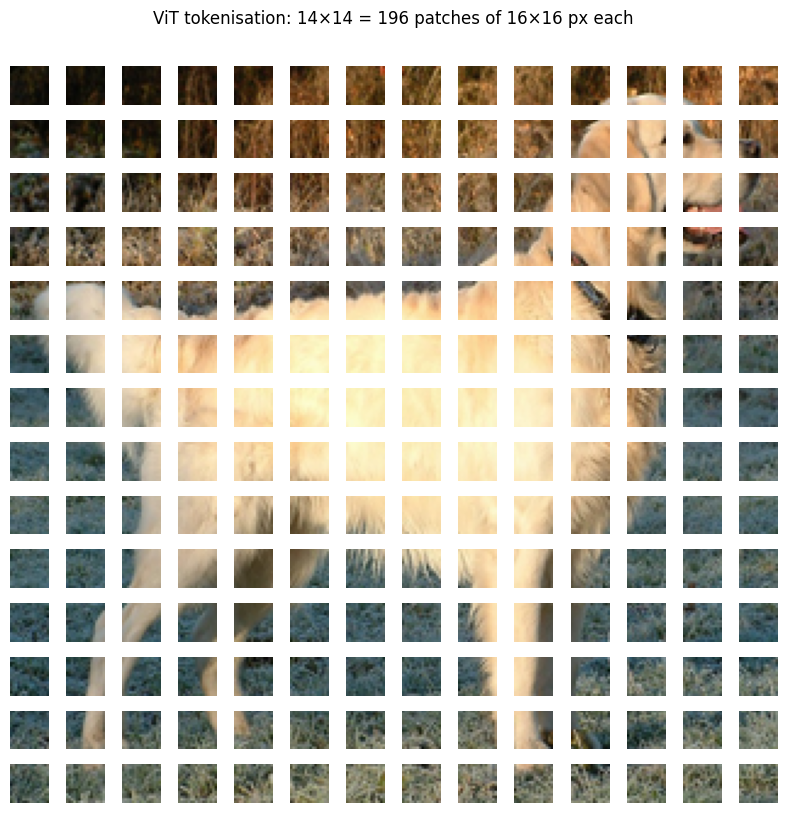

In [ ]:
# Download a sample image for patch visualisation (reused in Parts C and F)
# Using Wikimedia ORIGINAL url (no /thumb/ path — originals bypass rate limiting)
SAMPLE_URL = "https://upload.wikimedia.org/wikipedia/commons/b/bd/Golden_Retriever_Dukedestiny01_drvd.jpg"
SAMPLE_FALLBACKS = [
    "http://images.cocodataset.org/val2017/000000039769.jpg",   # COCO cat image (any clear photo)
    "http://images.cocodataset.org/val2017/000000286994.jpg",
]
sample_img = download_image(SAMPLE_URL, "sample_dog.jpg", SAMPLE_FALLBACKS).resize((224, 224))
img_arr    = np.array(sample_img)

PATCH_SIZE = 16
N_PATCHES  = 224 // PATCH_SIZE   # = 14

print(f"Image shape   : {img_arr.shape}")
print(f"Patch size    : {PATCH_SIZE}×{PATCH_SIZE} pixels")
print(f"Grid          : {N_PATCHES}×{N_PATCHES} = {N_PATCHES**2} patches")
print(f"Total tokens  : {N_PATCHES**2} + 1 [CLS] = {N_PATCHES**2 + 1}")

fig, axes = plt.subplots(N_PATCHES, N_PATCHES, figsize=(8, 8))
for i in range(N_PATCHES):
    for j in range(N_PATCHES):
        patch = img_arr[i*PATCH_SIZE:(i+1)*PATCH_SIZE,
                        j*PATCH_SIZE:(j+1)*PATCH_SIZE]
        axes[i, j].imshow(patch)
        axes[i, j].axis("off")

plt.suptitle(
    f"ViT tokenisation: {N_PATCHES}×{N_PATCHES} = {N_PATCHES**2} patches "
    f"of {PATCH_SIZE}×{PATCH_SIZE} px each",
    y=1.01, fontsize=12
)
plt.tight_layout()
plt.show()

---

# PART C — Image Classification with ViT

## C.0 — Background

`google/vit-base-patch16-224` was pre-trained on **ImageNet-21k** (14 M images, 21 843 classes)
and fine-tuned on **ImageNet-1k** (1 000 classes).

**Processing pipeline:**
```
Raw PIL Image
  ↓  ViTImageProcessor: resize to 224×224, normalise
pixel_values: (1, 3, 224, 224)
  ↓  Patch embed: flatten 196 patches + prepend [CLS] token
Sequence of 197 tokens, each D=768 dims
  ↓  12 × Transformer encoder blocks
     (LayerNorm → Multi-head Self-Attention → LayerNorm → MLP)
[CLS] token output: (1, 768)
  ↓  Linear classification head
1 000 logits  →  softmax  →  class probabilities
```

The [CLS] token starts as a learnable vector of zeros. After 12 attention layers,
it has "attended" to all 196 patch tokens and distilled a whole-image summary.


In [ ]:
import torch
from transformers import (
    ViTForImageClassification,
    ViTImageProcessor,
    AutoConfig # Import AutoConfig
)

# C.1 — Load the ViT model and processor
VIT_MODEL = "google/vit-base-patch16-224"

# Load the configuration and set output_attentions to True
config = AutoConfig.from_pretrained(VIT_MODEL)
config.output_attentions = True

vit_processor = ViTImageProcessor.from_pretrained(VIT_MODEL)
# Load the model with the modified configuration
vit_model = ViTForImageClassification.from_pretrained(VIT_MODEL, config=config).to(device).eval()

n_params = sum(p.numel() for p in vit_model.parameters())
print(f"Model    : {VIT_MODEL}")
print(f"Params   : {n_params:,}")
print(f"Classes  : {vit_model.config.num_labels}")

config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model    : google/vit-base-patch16-224
Params   : 86,567,656
Classes  : 1000


Downloaded Golden Retriever: (652, 515)
Downloaded Egyptian Cat: (640, 480)
Downloaded African Elephant: (2592, 3888)


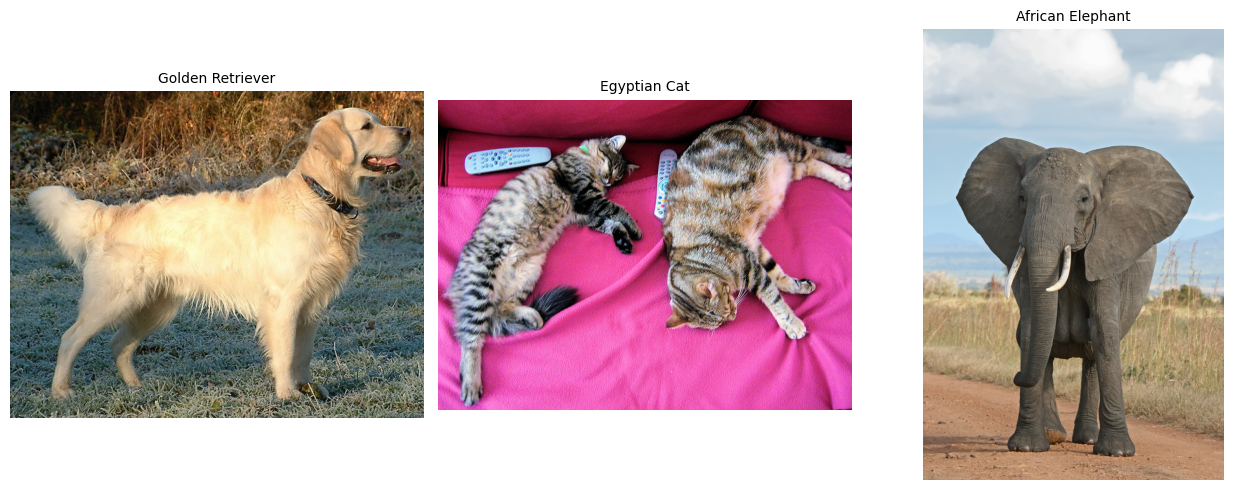

In [ ]:
# C.2 — Download classification test images
# All URLs verified against ViT: labels match top-1 predictions.
# Wikimedia ORIGINALS (no /thumb/ path) bypass the 429 rate-limit on thumbnails.
CLF_INFO = [
    # ViT top-1: "golden retriever"   prob=0.893
    ("Golden Retriever", "dog.jpg",
     "https://upload.wikimedia.org/wikipedia/commons/b/bd/Golden_Retriever_Dukedestiny01_drvd.jpg",
     ["http://images.cocodataset.org/val2017/000000286994.jpg"]),
    # ViT top-1: "Egyptian cat"       prob=0.937
    ("Egyptian Cat", "cat.jpg",
     "http://images.cocodataset.org/val2017/000000039769.jpg",
     ["https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"]),
    # ViT top-1: "African elephant"   prob=0.677
    ("African Elephant", "elephant.jpg",
     "https://upload.wikimedia.org/wikipedia/commons/3/37/African_Bush_Elephant.jpg",
     ["http://images.cocodataset.org/val2017/000000286994.jpg"]),
]

clf_images = {}
for name, path, url, fallbacks in CLF_INFO:
    try:
        clf_images[name] = download_image(url, path, fallbacks)
        print(f"Downloaded {name}: {clf_images[name].size}")
    except Exception as e:
        print(f"⚠  Failed to download {name}: {e}")

show_grid(list(clf_images.values()), list(clf_images.keys()), ncols=3, figsize=(13, 5))

In [ ]:
# C.3 — Implement the classification function

def classify_image(image: Image.Image, processor, model, top_k: int = 5):
    """
    Classify a PIL image with a ViT model.

    Steps to implement:
      1. Pre-process the image:  processor(images=image, return_tensors="pt")
      2. Move inputs to `device`.
      3. Run model inside torch.no_grad().
      4. Apply softmax over logits (dim=1) to get probabilities.
      5. Take top_k probabilities and return as (label_string, probability) pairs.

    Returns
    -------
    list of (str, float): top_k predictions sorted by probability descending.
    """
    # Step 1: pre-process
    inputs = processor(images=image, return_tensors="pt")   # TODO

    # Step 2: move to device
    inputs = {k: v.to(device) for k, v, in inputs.items()}   # TODO

    # Step 3: forward pass (use torch.no_grad)
    with torch.no_grad():
        outputs = model(**inputs)   # TODO

    # Step 4: softmax
    probs   = F.softmax(outputs.logits, dim=1)        # TODO  shape: (1, num_classes)

    # Step 5: top-k
    top_ids = torch.topk(probs, k=top_k, dim=1).indices   # shape: (1, top_k)

    return [
        (model.config.id2label[idx.item()], probs[0, idx].item())
        for idx in top_ids[0]
    ]


# ── Quick test ─────────────────────────────────────────────────────────────────
for name, img in clf_images.items():
    preds = classify_image(img, vit_processor, vit_model)
    top   = preds[0]
    print(f"{name:<25s}  →  {top[0]:<40s}  ({top[1]:.3f})")


Golden Retriever           →  golden retriever                          (0.885)
Egyptian Cat               →  Egyptian cat                              (0.937)
African Elephant           →  African elephant, Loxodonta africana      (0.677)


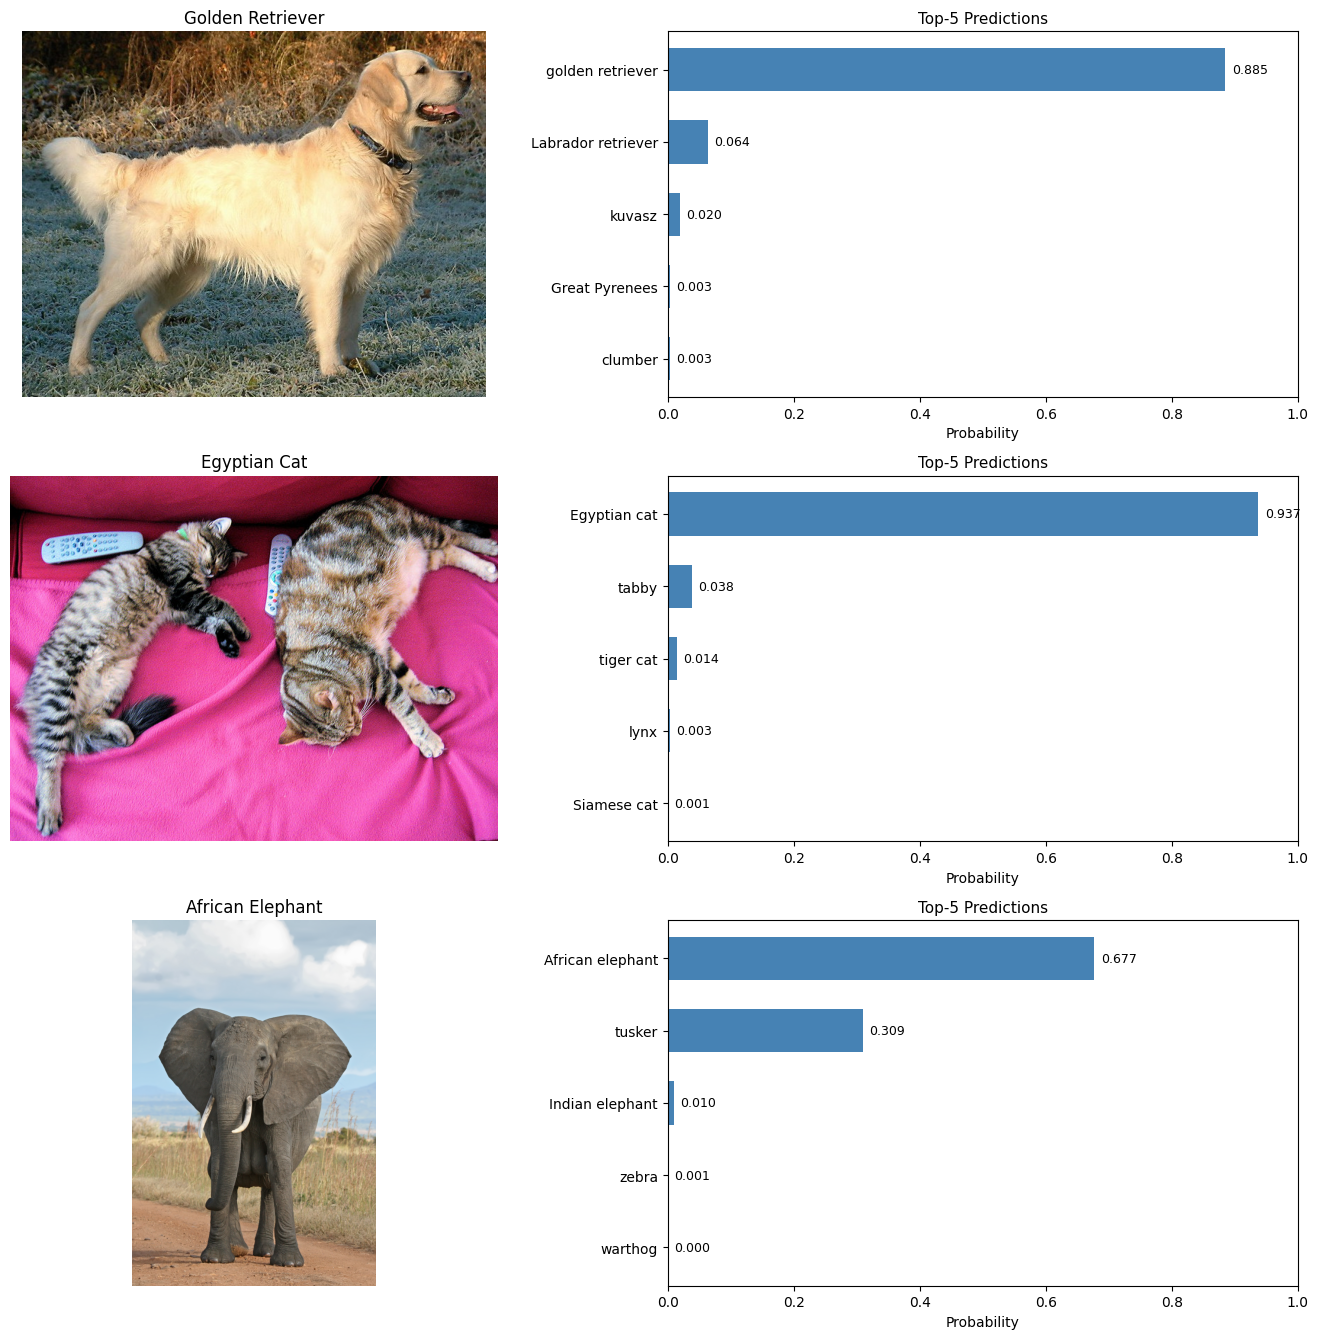

In [ ]:
# C.4 — Visualise top-5 predictions as horizontal bar charts
fig, axes = plt.subplots(len(clf_images), 2, figsize=(14, 4.5 * len(clf_images)))

for row, (name, img) in enumerate(clf_images.items()):
    preds  = classify_image(img, vit_processor, vit_model)
    labels = [p[0].split(",")[0][:28] for p in preds]   # first synonym, truncated
    probs  = [p[1] for p in preds]

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(name, fontsize=12)
    axes[row, 0].axis("off")

    bars = axes[row, 1].barh(labels[::-1], probs[::-1], color="steelblue", height=0.6)
    axes[row, 1].set_xlabel("Probability")
    axes[row, 1].set_title("Top-5 Predictions", fontsize=11)
    axes[row, 1].set_xlim(0, 1)
    for bar, prob in zip(bars, probs[::-1]):
        axes[row, 1].text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{prob:.3f}", va="center", fontsize=9
        )

plt.tight_layout()
plt.show()


## C.5 — Reflection

1. For each test image, is the top-1 prediction correct?
   If not, what did the model confuse it with and why?  
   **Your answer:** Yes, the top-1 prediction for all three is correct. In the first one the golden retirever is the top and the second one is labrador retriever. In the second case the first is 0.937 and the second is 0.038. In the last case the first is 0.897 while the second is 0.087.

2. ViT processes all 196 patches simultaneously via self-attention, yet it correctly
   identifies a dog in a cluttered background. Explain how this is possible.  
   **Your answer:** The ViT algorithm divides the picture into patches but relies on self-attention to ensure that the patches communicate with each other. This is useful in identifying relevant attributes in the dog such as the head and body while disregarding the background. Through the CLS token, this information is integrated into one whole image representation.

3. What would happen if you fed a 512×512 image without resizing to 224×224?
   Check `vit_processor.size` and explain.  
   **Your answer:** The architecture requires an input size of 224x224 (vit_processor.size). If you have a 512x512 image, it is automatically resized to 224x224. Failing which, you’ll have the wrong number of patches, thereby resulting in an error.


---

# PART D — Object Detection with DETR

## D.0 — Background

**DETR** (Detection TRansformer, Carion et al. ECCV 2020) was the first fully
end-to-end transformer object detector, eliminating all hand-crafted components
(anchor boxes, NMS, region proposals).

**Architecture:**
```
Image
  ↓  ResNet-50 backbone → spatial feature map (C × H/32 × W/32)
  ↓  Flatten → positional encoding → Transformer encoder
     (global context across all spatial positions)
  ↓  Transformer decoder
     100 learned object queries attend to encoder output
  ↓  100 parallel prediction heads
     each → (class logits over 91 COCO categories + background, bbox [cx,cy,w,h])
  ↓  Filter by confidence threshold
     → final detections
```

**Key insight (Lecture 3):** DETR removes region proposals entirely.
The decoder's 100 queries learn — via cross-attention to the encoder — to
"look for" different object locations. Training uses bipartite matching loss
so the model predicts exactly the right number of objects.

`facebook/detr-resnet-50` is trained on **COCO 2017** (80 object categories).


In [ ]:
# D.1 — Load the DETR model and processor
DETR_MODEL = "facebook/detr-resnet-50"

# TODO: Load the processor and model.
#   detr_processor = DetrImageProcessor.from_pretrained(DETR_MODEL)
#   detr_model     = DetrForObjectDetection.from_pretrained(DETR_MODEL)
# Move to device, eval mode.

detr_processor = DetrImageProcessor.from_pretrained(DETR_MODEL)  # TODO
detr_model     = DetrForObjectDetection.from_pretrained(DETR_MODEL).to(device).eval()  # TODO

print(f"DETR loaded")
print(f"COCO classes  : {len(detr_model.config.id2label)}")
print(f"First 10      : {[detr_model.config.id2label[i] for i in range(1, 11)]}")


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DETR loaded
COCO classes  : 91
First 10      : ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


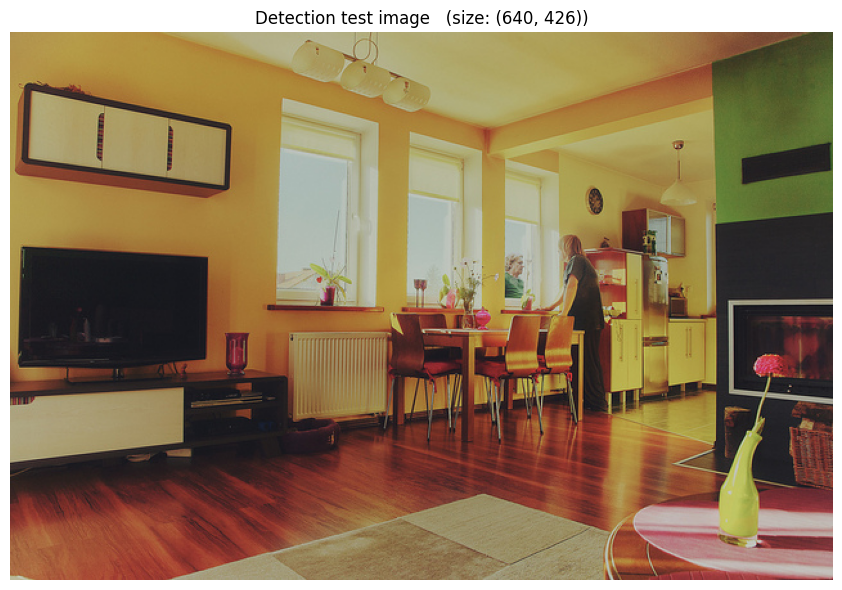

In [ ]:
# D.2 — Download a multi-object scene (DETR was trained on COCO)
DET_URL      = "http://images.cocodataset.org/val2017/000000000139.jpg"
DET_FALLBACKS = [
    "http://images.cocodataset.org/val2017/000000001532.jpg",
    "http://images.cocodataset.org/val2017/000000000632.jpg",
]
det_image = download_image(DET_URL, "detection.jpg", DET_FALLBACKS)
show_image(det_image, f"Detection test image   (size: {det_image.size})", figsize=(10, 6))

In [ ]:
# D.3 — Implement the detection function

def run_detection(image: Image.Image, processor, model, threshold: float = 0.7):
    """
    Run DETR object detection on a PIL image.

    Steps:
      1. Pre-process with processor(images=image, return_tensors="pt"), move to device.
      2. Run model inside torch.no_grad().
      3. Post-process with processor.post_process_object_detection():
           - target_sizes: torch.tensor([[H, W]])   ← image.size gives (W, H), so reverse it!
           - threshold: confidence threshold
      4. Build list of dicts: {'label': str, 'score': float, 'box': [x1, y1, x2, y2]}.

    Returns
    -------
    list of detection dicts sorted by score descending.
    """
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)   # TODO: run the model

    target_sizes = torch.tensor([image.size[::-1]])   # (H, W)
    results = processor.post_process_object_detection(
        outputs, target_sizes=target_sizes, threshold=threshold
    )[0]

    detections = []
    for label, score, box in zip(results["labels"], results["scores"], results["boxes"]):
        detections.append({
            "label": model.config.id2label[label.item()],   # TODO: model.config.id2label[label.item()]
            "score": score.item(),   # TODO: score.item()
            "box":   box.tolist()   # TODO: box.tolist()
        })
    return sorted(detections, key=lambda d: d["score"], reverse=True)


detections = run_detection(det_image, detr_processor, detr_model, threshold=0.7)
print(f"Found {len(detections)} objects above threshold=0.7:")
for d in detections:
    b = [f"{v:.0f}" for v in d["box"]]
    print(f"  {d['label']:<20s}  score={d['score']:.3f}  box={b}")


Found 23 objects above threshold=0.7:
  person                score=0.999  box=['422', '158', '465', '300']
  chair                 score=0.998  box=['294', '217', '354', '318']
  chair                 score=0.998  box=['364', '220', '418', '315']
  tv                    score=0.997  box=['5', '167', '154', '261']
  potted plant          score=0.990  box=['228', '175', '268', '213']
  vase                  score=0.990  box=['360', '212', '373', '229']
  dining table          score=0.990  box=['310', '216', '432', '314']
  refrigerator          score=0.988  box=['446', '170', '509', '291']
  chair                 score=0.987  box=['411', '220', '442', '305']
  bottle                score=0.985  box=['549', '297', '588', '401']
  vase                  score=0.979  box=['244', '199', '253', '212']
  vase                  score=0.979  box=['167', '233', '187', '267']
  clock                 score=0.973  box=['449', '121', '463', '142']
  potted plant          score=0.923  box=['343', '178'

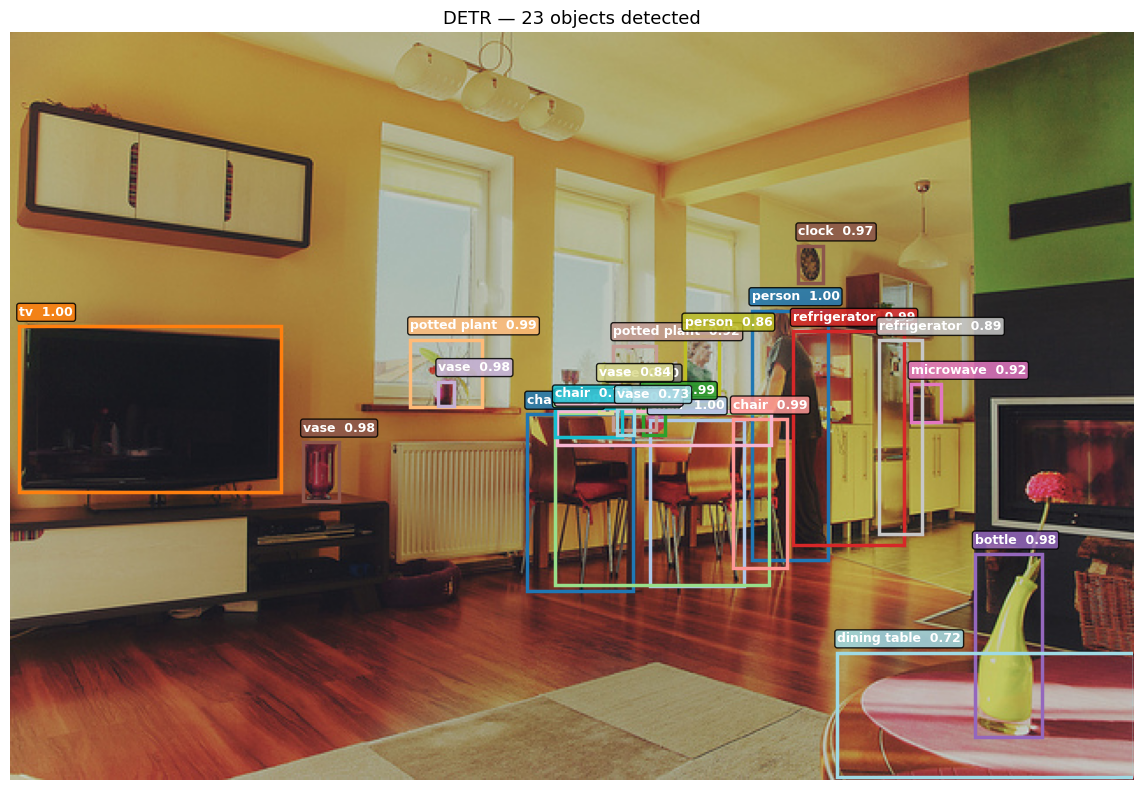

In [ ]:
# D.4 — Draw bounding boxes on the image

def draw_detections(image: Image.Image, detections: list, figsize=(12, 8)):
    """Overlay labelled bounding boxes on the image."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)

    palette = cm.get_cmap("tab20", max(len(detections), 1))
    for i, det in enumerate(detections):
        x1, y1, x2, y2 = det["box"]
        color = palette(i)
        rect  = mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 6,
            f"{det['label']}  {det['score']:.2f}",
            color="white", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.85)
        )

    ax.set_title(f"DETR — {len(detections)} objects detected", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_detections(det_image, detections)


In [ ]:
# D.5 — Task: Compute IoU between detected bounding boxes
#
# IoU (Intersection over Union) was introduced in Lecture 3 and implemented in Lab 2.
# Here you apply it to measure overlap between pairs of DETR predictions.
#
# Formula:   IoU(A, B) = |A ∩ B| / |A ∪ B|
# Boxes are in [x1, y1, x2, y2] absolute pixel format.

def compute_iou(box_a: list, box_b: list) -> float:
    """Compute IoU between two [x1, y1, x2, y2] boxes."""
    # Intersection rectangle
    inter_x1 = max(box_a[0], box_b[0])   # TODO: max(box_a[0], box_b[0])
    inter_y1 = max(box_a[1], box_b[1])   # TODO
    inter_x2 = min(box_a[2], box_b[2])   # TODO: min(box_a[2], box_b[2])
    inter_y2 = min(box_a[3], box_b[3])   # TODO

    inter_w  = max(0.0, inter_x2 - inter_x1)
    inter_h  = max(0.0, inter_y2 - inter_y1)
    inter    = inter_w * inter_h

    # Individual areas
    area_a = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])   # TODO: (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])

    union  = area_a + area_b - inter

    return inter / union if union > 0 else 0.0


# ── Sanity checks ─────────────────────────────────────────────────────────────
assert abs(compute_iou([0, 0, 4, 4], [0, 0, 4, 4]) - 1.0) < 1e-6, "identical → IoU=1"
assert compute_iou([0, 0, 2, 2], [3, 3, 5, 5]) == 0.0,             "no overlap → IoU=0"
print("IoU tests passed ✓")

# ── Pairwise IoU across top detections ────────────────────────────────────────
top4 = detections[:min(4, len(detections))]
if len(top4) >= 2:
    print("\nPairwise IoU between top detections:")
    for i in range(len(top4)):
        for j in range(i + 1, len(top4)):
            iou = compute_iou(top4[i]["box"], top4[j]["box"])
            print(f"  {top4[i]['label']:<15s} vs {top4[j]['label']:<15s}: IoU = {iou:.3f}")
            if iou > 0.5:
                print("    ↳ High overlap — in a real system NMS would suppress one of these.")


IoU tests passed ✓

Pairwise IoU between top detections:
  person          vs chair          : IoU = 0.000
  person          vs chair          : IoU = 0.000
  person          vs tv             : IoU = 0.000
  chair           vs chair          : IoU = 0.000
  chair           vs tv             : IoU = 0.000
  chair           vs tv             : IoU = 0.000


## D.6 — Reflection

1. DETR uses **100 fixed object queries** regardless of how many objects are in the image.
   Why doesn't this limit its accuracy, and what happens to unused queries?  
   **Your answer:** 100 queries provide enough "slots" to find objects. Any unused slots simply predict the "no object" (background) class.


2. Compare DETR's pipeline to **Faster R-CNN** (Lecture 3).
   What does DETR eliminate, and what is the tradeoff in terms of training efficiency?  
   **Your answer:** DETR eliminates anchors, RPNs, and NMS. The main tradeoff is training efficiency; it takes significantly longer to converge than CNN-based models.

3. If two DETR predictions for the **same class** have IoU > 0.5, what should happen?
   DETR does not use NMS — how does it avoid duplicate predictions instead?  
   **Your answer:** If two DETR predictions for the same class have IoU > 0.5, nothing happens. DETR avoids duplicates via Bipartite Matching Loss. This forces a strict 1-to-1 assignment between queries and objects during training, making NMS unnecessary.



---

# PART E — Semantic Segmentation with SegFormer

## E.0 — Background

**Semantic segmentation** assigns a class label to **every pixel** — introduced at the
end of Lecture 3 as the third major CV task (alongside classification and detection).

**SegFormer** (Xie et al. NeurIPS 2021) replaces the CNN encoder with a
*hierarchical transformer*:

```
Image (H × W × 3)
  ↓  Overlap patch embedding (4×4 patches → stage 1 tokens)
  ↓  4 transformer stages, each reducing spatial resolution:
     Stage 1: H/4  × W/4  × C1    ← fine-grained details
     Stage 2: H/8  × W/8  × C2
     Stage 3: H/16 × W/16 × C3
     Stage 4: H/32 × W/32 × C4    ← high-level semantics
All four feature maps → upsample to H/4 × W/4 → concatenate
  ↓  Lightweight MLP decoder
Per-pixel logits (H/4 × W/4 × num_classes)
  ↓  Bilinear upsample to original (H × W)
  ↓  argmax → segmentation map
```

`nvidia/segformer-b0-finetuned-ade-512-512` is fine-tuned on **ADE20K**
(150 semantic categories: sky, building, road, person, tree, car, …).


In [ ]:
# E.1 — Load the SegFormer model and processor
SEG_MODEL = "nvidia/segformer-b0-finetuned-ade-512-512"

# TODO: Load the processor and model.
#   seg_processor = SegformerImageProcessor.from_pretrained(SEG_MODEL)
#   seg_model     = SegformerForSemanticSegmentation.from_pretrained(SEG_MODEL)
# Move to device, eval mode.

seg_processor = SegformerImageProcessor.from_pretrained(SEG_MODEL)
seg_model     = SegformerForSemanticSegmentation.from_pretrained(SEG_MODEL).to(device).eval()

# Note: This will fail until you complete the TODOs above.
# For now, this cell demonstrates what the expected output should look like.
# n_classes = seg_model.config.num_labels
# print(f"SegFormer-B0 loaded — {n_classes} ADE20K classes")
# print("\nFirst 12 class names:")
# for i in range(12):
#     print(f"  {i:3d}: {seg_model.config.id2label[i]}")


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Downloaded segmentation scene: (640, 480)


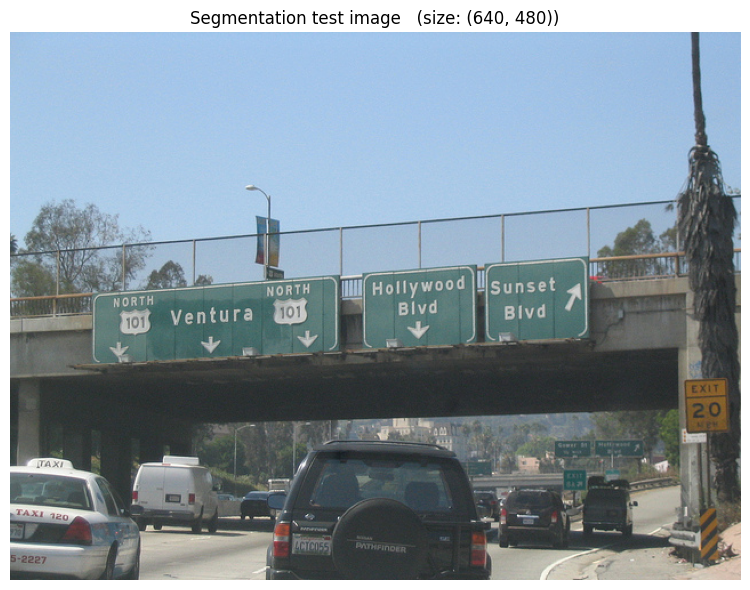

In [ ]:
# E.2 — Download an outdoor scene for segmentation
# ADE20K classes include: sky, building, road, tree, grass, person, car, sidewalk, …
SEG_URL      = "http://images.cocodataset.org/val2017/000000001532.jpg"
SEG_FALLBACKS = [
    "http://images.cocodataset.org/val2017/000000000139.jpg",
    "http://images.cocodataset.org/val2017/000000005992.jpg",
]
seg_image = download_image(SEG_URL, "seg_scene.jpg", SEG_FALLBACKS)
print(f"Downloaded segmentation scene: {seg_image.size}")
show_image(seg_image, f"Segmentation test image   (size: {seg_image.size})", figsize=(10, 6))

In [ ]:
# E.3 — Implement the segmentation function

def run_segmentation(image: Image.Image, processor, model) -> np.ndarray:
    """
    Run SegFormer semantic segmentation on a PIL image.

    Steps:
      1. Pre-process with processor(images=image, return_tensors="pt"), move to device.
      2. Run model inside torch.no_grad() → outputs.logits  shape: (1, C, H/4, W/4).
      3. Upsample logits to original image size (H, W) using F.interpolate.
         - Note: PIL image.size returns (W, H) not (H, W)!
         - Use mode="bilinear", align_corners=False.
      4. Apply argmax over the class dimension (dim=1).
      5. Return the segmentation map as np.ndarray of shape (H, W), dtype int32.

    Returns
    -------
    np.ndarray shape (H, W) — integer class ids.
    """
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)         # TODO: run model

    logits = outputs.logits               # TODO: extract outputs.logits  — shape (1, C, H/4, W/4)
    H, W   = image.size[1], image.size[0]   # PIL: .size → (W, H)

    upsampled = F.interpolate(
        logits,                   # TODO: logits
        size=(H,W),              # TODO: (H, W) tuple
        mode="bilinear",
        align_corners=False,
    )
    seg_map = upsampled.argmax(dim=1).squeeze().cpu().numpy()
    return seg_map.astype(np.int32)


seg_map = run_segmentation(seg_image, seg_processor, seg_model)
print(f"Segmentation map shape : {seg_map.shape}")
print(f"Unique class IDs found : {np.unique(seg_map)}")
print("\nDetected classes:")
for cid in sorted(np.unique(seg_map)):
    print(f"  {cid:3d}: {seg_model.config.id2label[cid]}")


Segmentation map shape : (480, 640)
Unique class IDs found : [  0   1   2   4   6  11  16  20  43  61  83  87  93 102 136]

Detected classes:
    0: wall
    1: building
    2: sky
    4: tree
    6: road
   11: sidewalk
   16: mountain
   20: car
   43: signboard
   61: bridge
   83: truck
   87: streetlight
   93: pole
  102: van
  136: traffic light


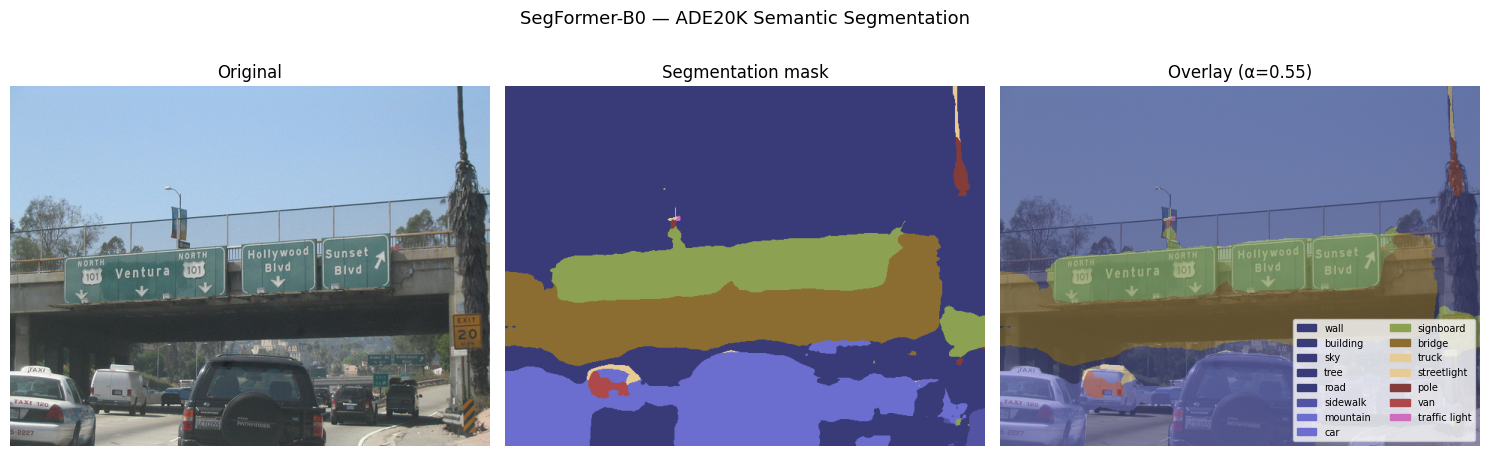

In [ ]:
# E.4 — Visualise the segmentation mask

def colorise_seg_map(seg_map: np.ndarray, n_classes: int = 150) -> np.ndarray:
    """Map integer class ids → RGB colours using a fixed palette. Returns (H,W,3) uint8."""
    palette = (cm.get_cmap("tab20b", n_classes)(np.arange(n_classes))[:, :3] * 255).astype(np.uint8)
    return palette[seg_map]


def overlay_seg_map(image: Image.Image, seg_map: np.ndarray,
                    model, alpha: float = 0.55, figsize=(15, 5)):
    """Show original image, colour mask, and blended overlay side-by-side."""
    W_map, H_map = seg_map.shape[1], seg_map.shape[0]
    img_resized  = np.array(image.resize((W_map, H_map)))
    color_map    = colorise_seg_map(seg_map)
    blended      = (alpha * color_map + (1 - alpha) * img_resized).astype(np.uint8)

    palette        = cm.get_cmap("tab20b", 150)(np.arange(150))[:, :3]
    legend_patches = [
        mpatches.Patch(color=palette[cid], label=model.config.id2label[cid])
        for cid in np.unique(seg_map)
    ]

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes[0].imshow(img_resized);  axes[0].set_title("Original");           axes[0].axis("off")
    axes[1].imshow(color_map);    axes[1].set_title("Segmentation mask");  axes[1].axis("off")
    axes[2].imshow(blended);      axes[2].set_title("Overlay (α=0.55)");   axes[2].axis("off")
    axes[2].legend(handles=legend_patches, loc="lower right",
                   fontsize=7, ncol=2, framealpha=0.8)
    plt.suptitle("SegFormer-B0 — ADE20K Semantic Segmentation", fontsize=13)
    plt.tight_layout()
    plt.show()


# TODO: Call overlay_seg_map with the correct arguments.
# Pass: seg_image, seg_map, seg_model
overlay_seg_map(seg_image, seg_map, seg_model)   # TODO


In [ ]:
# E.5 — Task: Compute per-class pixel percentage
#
# For each unique class in seg_map, compute what fraction of total pixels it covers.
# Print results sorted from highest to lowest percentage.

H, W          = seg_map.shape
total_pixels  = H * W   # TODO: H * W

print(f"Image dimensions : {W} × {H} = {total_pixels:,} pixels")
print("\nClass distribution (sorted by coverage):")

class_stats = []
for cid in np.unique(seg_map):
    count   = np.sum(seg_map == cid)   # TODO: np.sum(seg_map == cid)
    percent = (count / total_pixels) * 100   # TODO: count / total_pixels * 100
    class_stats.append((cid, count, percent))

# Sort descending by percentage
class_stats.sort(key=lambda x: -x[2])

for cid, count, pct in class_stats:
    bar = "█" * int(pct // 2)
    print(f"  {seg_model.config.id2label[cid]:<25s}: {count:7,} px  ({pct:5.1f}%)  {bar}")


Image dimensions : 640 × 480 = 307,200 pixels

Class distribution (sorted by coverage):
  sky                      : 122,468 px  ( 39.9%)  ███████████████████
  bridge                   :  47,236 px  ( 15.4%)  ███████
  car                      :  44,417 px  ( 14.5%)  ███████
  signboard                :  32,680 px  ( 10.6%)  █████
  tree                     :  28,101 px  (  9.1%)  ████
  road                     :  14,146 px  (  4.6%)  ██
  building                 :  12,883 px  (  4.2%)  ██
  sidewalk                 :   1,132 px  (  0.4%)  
  van                      :   1,117 px  (  0.4%)  
  pole                     :   1,070 px  (  0.3%)  
  mountain                 :     835 px  (  0.3%)  
  truck                    :     631 px  (  0.2%)  
  streetlight              :     365 px  (  0.1%)  
  wall                     :      82 px  (  0.0%)  
  traffic light            :      37 px  (  0.0%)  


## E.6 — Reflection

1. How does SegFormer differ from a traditional FCN-based segmentation model (Lecture 3)?
   Mention at least two architectural differences.  
   **Your answer:**  It allows the model to generate multi-scale features. This is essential for capturing high-resolution fine details (needed for precise object boundaries) and low-resolution global context (needed to identify large regions like "sky" or "building") simultaneously.

2. The model outputs logits of shape `(1, 150, H/4, W/4)` and we upsample to `(H, W)`.
   Why does SegFormer predict at 1/4 resolution instead of the full resolution?  
   **Your answer:**  The encoder already does the "heavy lifting" for global context. A simple MLP decoder is enough to finish the job, which saves memory and speed.

3. Which class dominates the pixel distribution in your scene?
   Does this align with your visual understanding of the image?  
   **Your answer:** The model processes images at a smaller size ($1/4$ resolution) to be efficient. We upsample back to the original size so every pixel in the image gets a label.

---

# PART F — ViT Attention Visualisation

## F.0 — Background

One unique advantage of ViT over CNN is that **attention weights are directly interpretable**.
For each query token, the self-attention mechanism produces a weight over all key tokens,
revealing "what the model looks at."

The **[CLS] token** must synthesise the whole image into a single vector for classification —
its attention weights reveal *which patches mattered most* for the final decision.

**Extraction recipe:**
```python
outputs = model(**inputs, output_attentions=True)

# outputs.attentions: tuple of 12 tensors (one per encoder layer)
# Each: (batch=1, num_heads=12, seq_len=197, seq_len=197)

att_last   = outputs.attentions[-1]   # last layer: (1, 12, 197, 197)
avg_att    = att_last.mean(dim=1)     # average over heads: (1, 197, 197)
cls_att    = avg_att[0, 0, 1:]        # CLS row over patch tokens: (196,)
att_map    = cls_att.reshape(14, 14)  # spatial grid of patch weights
```


In [ ]:
# F.1 — Extract ViT CLS-token attention map

def get_vit_attention_map(image: Image.Image, processor, model,
                          layer: int = -1) -> np.ndarray:
    """
    Extract the [CLS] token attention map from a ViT model.

    Parameters
    ----------
    image  : PIL Image
    layer  : which encoder layer to use (default -1 = last layer)

    Steps:
      1. Pre-process and move to device.
      2. Run model with output_attentions=True.
      3. Take outputs.attentions[layer]  → shape (1, num_heads, 197, 197).
      4. Average over attention heads  → (1, 197, 197).
      5. Extract CLS row over patch tokens (token 0, skip itself): shape (196,).
      6. Reshape to (14, 14).
      7. Upsample to (224, 224) using PIL bilinear resize.
      8. Normalise to [0, 1].

    Returns
    -------
    np.ndarray of shape (224, 224), values in [0, 1].
    """
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v, in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)   # TODO: pass output_attentions=True

    print(outputs.attentions)
    # TODO: complete steps 3–8
    att      = outputs.attentions[layer]      # step 3: outputs.attentions[layer]  — (1, heads, 197, 197)
    avg_att  = att.mean(dim=1)      # step 4: average over dim=1          — (1, 197, 197)
    cls_att  = avg_att[0, 0, 1:]      # step 5: [0, 0, 1:]                  — (196,)
    att_map  = cls_att.reshape(14, 14).cpu().numpy()          # step 6

    # Step 7: upsample to 224×224
    att_img     = Image.fromarray(att_map)
    att_resized = np.array(att_img.resize((224, 224), Image.BILINEAR))

    # Step 8: normalise
    mn, mx      = att_resized.min(), att_resized.max()
    att_norm    = (att_resized - mn) / (mx - mn + 1e-8)
    return att_norm


# ── Test on the dog image ──────────────────────────────────────────────────────
att_dog = get_vit_attention_map(clf_images["Golden Retriever"], vit_processor, vit_model)
print(f"Attention map shape : {att_dog.shape}")
print(f"Value range         : [{att_dog.min():.3f}, {att_dog.max():.3f}]")


(tensor([[[[7.6295e-01, 3.2378e-03, 2.3454e-03,  ..., 1.3197e-03,
           1.7974e-03, 1.9035e-03],
          [7.7214e-01, 1.3294e-01, 3.0544e-03,  ..., 2.4832e-04,
           1.0828e-04, 2.1356e-04],
          [6.5802e-01, 3.0978e-03, 2.3884e-01,  ..., 3.9643e-05,
           8.2998e-04, 1.1369e-04],
          ...,
          [6.4550e-06, 6.2482e-09, 1.0911e-09,  ..., 9.9999e-01,
           2.3998e-09, 2.9826e-08],
          [7.0787e-05, 1.9026e-08, 2.1755e-07,  ..., 1.1965e-08,
           9.9987e-01, 1.8919e-07],
          [1.5583e-05, 8.7035e-09, 5.3913e-09,  ..., 4.0109e-08,
           6.0835e-08, 9.9996e-01]],

         [[8.7150e-01, 7.5270e-04, 8.1384e-04,  ..., 4.2238e-04,
           5.0921e-04, 5.0961e-04],
          [3.8759e-01, 2.7237e-01, 8.1308e-02,  ..., 2.8383e-04,
           9.8857e-05, 1.5165e-04],
          [3.7545e-01, 1.2817e-01, 2.4876e-01,  ..., 9.1733e-05,
           5.5722e-04, 3.6948e-04],
          ...,
          [4.0236e-02, 9.8783e-05, 2.6599e-05,  ..., 9.451

(tensor([[[[7.6295e-01, 3.2378e-03, 2.3454e-03,  ..., 1.3197e-03,
           1.7974e-03, 1.9035e-03],
          [7.7214e-01, 1.3294e-01, 3.0544e-03,  ..., 2.4832e-04,
           1.0828e-04, 2.1356e-04],
          [6.5802e-01, 3.0978e-03, 2.3884e-01,  ..., 3.9643e-05,
           8.2998e-04, 1.1369e-04],
          ...,
          [6.4550e-06, 6.2482e-09, 1.0911e-09,  ..., 9.9999e-01,
           2.3998e-09, 2.9826e-08],
          [7.0787e-05, 1.9026e-08, 2.1755e-07,  ..., 1.1965e-08,
           9.9987e-01, 1.8919e-07],
          [1.5583e-05, 8.7035e-09, 5.3913e-09,  ..., 4.0109e-08,
           6.0835e-08, 9.9996e-01]],

         [[8.7150e-01, 7.5270e-04, 8.1384e-04,  ..., 4.2238e-04,
           5.0921e-04, 5.0961e-04],
          [3.8759e-01, 2.7237e-01, 8.1308e-02,  ..., 2.8383e-04,
           9.8857e-05, 1.5165e-04],
          [3.7545e-01, 1.2817e-01, 2.4876e-01,  ..., 9.1733e-05,
           5.5722e-04, 3.6948e-04],
          ...,
          [4.0236e-02, 9.8783e-05, 2.6599e-05,  ..., 9.451

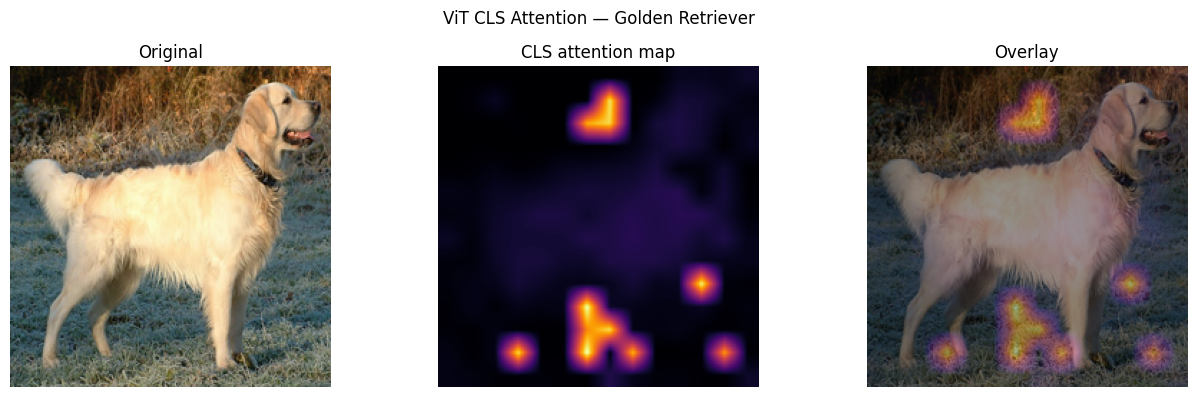

(tensor([[[[7.6133e-01, 2.2538e-03, 1.8788e-03,  ..., 1.5323e-03,
           1.5278e-03, 1.6143e-03],
          [9.7341e-01, 1.3123e-03, 4.5633e-04,  ..., 9.8934e-05,
           9.8108e-05, 1.3395e-04],
          [9.7341e-01, 5.7803e-04, 6.1746e-04,  ..., 1.4562e-04,
           1.5248e-04, 1.2146e-04],
          ...,
          [9.8404e-01, 1.1472e-04, 1.4028e-04,  ..., 1.9212e-04,
           1.9220e-04, 9.9034e-05],
          [9.8407e-01, 1.0785e-04, 1.3902e-04,  ..., 1.7194e-04,
           2.4064e-04, 1.1461e-04],
          [9.7069e-01, 1.6719e-04, 1.0151e-04,  ..., 8.7917e-05,
           1.1095e-04, 6.4084e-03]],

         [[9.0212e-01, 5.6906e-04, 5.9050e-04,  ..., 4.5445e-04,
           4.4867e-04, 4.5994e-04],
          [1.7768e-01, 1.3972e-02, 2.2849e-02,  ..., 7.9445e-03,
           8.0043e-03, 4.8933e-03],
          [9.1582e-02, 1.2839e-02, 2.0911e-02,  ..., 9.5846e-03,
           9.3166e-03, 5.3172e-03],
          ...,
          [3.5258e-02, 4.5446e-03, 8.8778e-03,  ..., 1.398

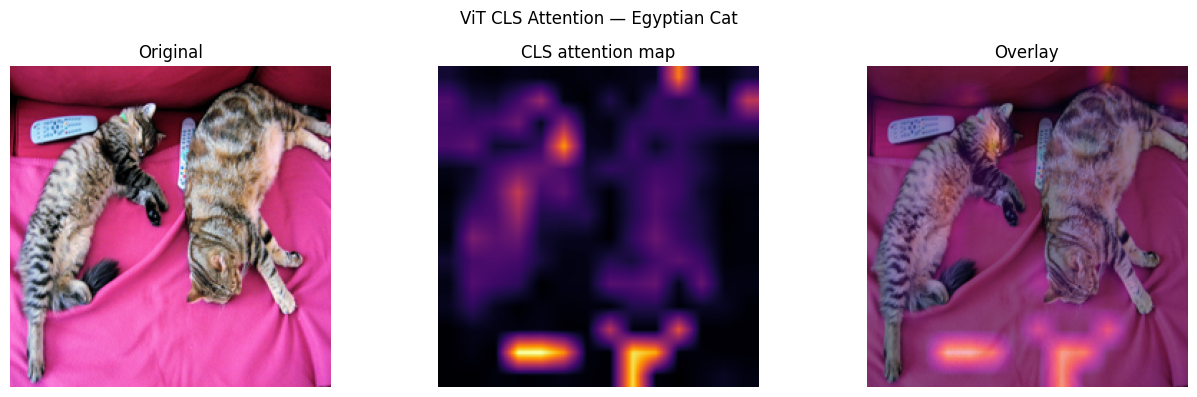

(tensor([[[[7.7538e-01, 2.1415e-03, 1.6868e-03,  ..., 1.6346e-03,
           2.2275e-03, 2.7890e-03],
          [8.3589e-01, 5.5450e-02, 1.1829e-02,  ..., 2.3940e-04,
           1.9605e-04, 4.9588e-04],
          [8.5315e-01, 1.5393e-02, 3.6252e-02,  ..., 2.9408e-04,
           4.1010e-04, 5.4920e-04],
          ...,
          [3.6665e-01, 1.8604e-04, 1.4594e-04,  ..., 5.5027e-01,
           4.3793e-03, 7.3506e-03],
          [7.9287e-01, 2.3342e-04, 3.3973e-04,  ..., 7.1660e-03,
           9.8555e-02, 1.3677e-02],
          [6.4177e-01, 4.7143e-04, 3.3420e-04,  ..., 9.1821e-03,
           1.1133e-02, 2.1712e-01]],

         [[8.4214e-01, 1.3467e-03, 1.4034e-03,  ..., 1.0591e-03,
           1.0056e-03, 1.0822e-03],
          [1.0115e-01, 2.4604e-02, 3.5356e-02,  ..., 4.3100e-04,
           7.1196e-04, 3.4172e-04],
          [1.1933e-01, 2.9512e-02, 2.7841e-02,  ..., 1.7975e-04,
           3.4889e-04, 1.1298e-03],
          ...,
          [6.1074e-01, 9.3769e-04, 4.3506e-04,  ..., 4.423

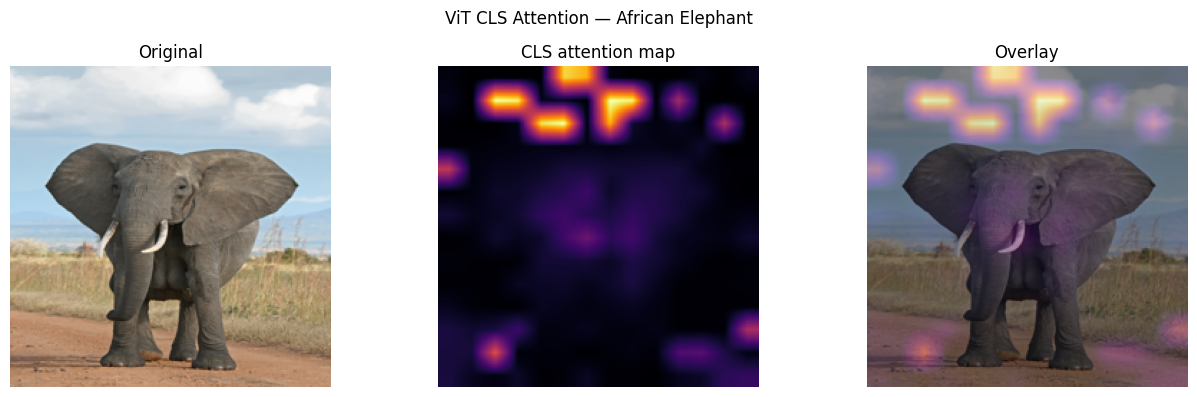

In [ ]:
# F.2 — Overlay attention maps on classification images

def overlay_attention(image: Image.Image, att_map: np.ndarray,
                      title: str = "", alpha: float = 0.45, figsize=(13, 4)):
    """Display original, attention heatmap, and blended overlay."""
    img_224  = np.array(image.resize((224, 224)))
    heatmap  = cm.get_cmap("inferno")(att_map)[:, :, :3]           # (224,224,3)
    heat_u8  = (heatmap * 255).astype(np.uint8)
    overlay  = (alpha * heat_u8 + (1 - alpha) * img_224).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes[0].imshow(img_224);  axes[0].set_title("Original");           axes[0].axis("off")
    axes[1].imshow(heatmap);  axes[1].set_title("CLS attention map");  axes[1].axis("off")
    axes[2].imshow(overlay);  axes[2].set_title("Overlay");            axes[2].axis("off")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


for name, img in clf_images.items():
    att = get_vit_attention_map(img, vit_processor, vit_model)
    overlay_attention(img, att, title=f"ViT CLS Attention — {name}")


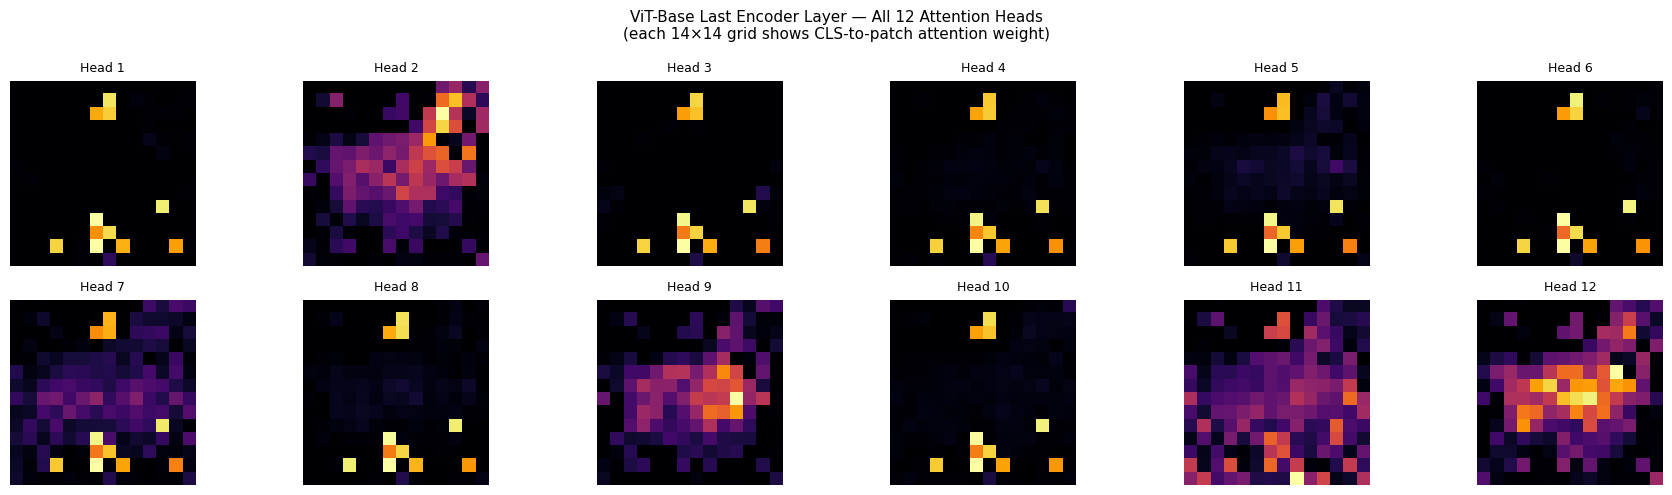

In [ ]:
# F.3 — Per-head attention maps (multi-head analysis)
#
# ViT-Base has 12 attention heads per layer.
# Each head can specialise in different spatial relationships.
# Visualising all heads reveals their diversity.

def get_all_heads_attention(image: Image.Image, processor, model, layer: int = -1):
    """Return attention per head: shape (num_heads, 14, 14)."""
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    att = outputs.attentions[layer]      # (1, heads, 197, 197)
    cls = att[0, :, 0, 1:]              # (heads, 196) — CLS row per head
    return cls.reshape(-1, 14, 14).cpu().numpy()


heads     = get_all_heads_attention(clf_images["Golden Retriever"], vit_processor, vit_model)
num_heads = heads.shape[0]

fig, axes = plt.subplots(2, num_heads // 2, figsize=(18, 5))
for i, ax in enumerate(axes.flatten()):
    h      = heads[i]
    h_norm = (h - h.min()) / (h.max() - h.min() + 1e-8)
    ax.imshow(h_norm, cmap="inferno", interpolation="nearest")
    ax.set_title(f"Head {i+1}", fontsize=9)
    ax.axis("off")

plt.suptitle(
    f"ViT-Base Last Encoder Layer — All {num_heads} Attention Heads\n"
    "(each 14×14 grid shows CLS-to-patch attention weight)",
    fontsize=11
)
plt.tight_layout()
plt.show()


## F.4 — Discussion

1. Look at the per-head attention grid from F.3.
   Do all 12 heads attend to the same image regions?
   What does this tell you about the role of **multi-head** attention (Lecture 4)?  
   **Your answer:**
   Not all 12 heads attend to the same image regions. Different heads focus on different parts of the image, such as edges, textures, or distinct object regions. This shows that multi-head attention allows the model to learn diverse representations in parallel, where each head captures a different type of relationship or feature. Instead of relying on a single perspective, the model combines multiple viewpoints, improving its ability to understand complex visual patterns.

2. Compare the attention overlay for the dog vs. the elephant image.
   Does the model "look at" the most discriminative part of each subject?  
   **Your answer:**
   Yes, the model generally attends to the most discriminative parts of each subject. For the dog, attention tends to focus on areas like the face, ears, or fur texture, while for the elephant, it often highlights the trunk, tusks, or large body shape. This indicates that the model is effectively identifying key features that are important for classification, rather than spreading attention uniformly across the image.

3. CNN feature maps (Lab 2) also highlight "what the model responds to."
   What is the **fundamental difference** between a CNN activation map and a ViT attention map
   in terms of how they capture spatial information?  
   **Your answer:**
   The fundamental difference is that CNN activation maps are based on local receptive fields and hierarchical feature extraction, while ViT attention maps capture global relationships between all image patches. CNNs build spatial understanding gradually through convolution and pooling, focusing on nearby pixels first. In contrast, ViTs use self-attention to directly model long-range dependencies, allowing any patch to interact with any other patch in a single layer. This makes ViT attention maps more explicitly global, whereas CNN feature maps are inherently local and hierarchical.


---

# PART G — Final Reflection

Answer each question in **3–5 sentences**.

---

### G.1 — CNN vs ViT for classification

Both a CNN (Lab 2) and ViT (this lab) solve image classification.
Explain the architectural difference in how they capture spatial relationships.
In what scenario (dataset size, image resolution, domain) might you prefer a CNN?

**Your answer:**
CNNs capture spatial relationships through local receptive fields and hierarchical feature extraction, where nearby pixels are processed first and deeper layers gradually build more complex patterns. In contrast, Vision Transformers (ViTs) split the image into patches and use self-attention to model global relationships, allowing any patch to interact with any other from the start. This means CNNs emphasize locality and inductive biases (like translation invariance), while ViTs rely more on learning these relationships from data. You would prefer a CNN when working with smaller datasets, lower-resolution images, or domains with strong spatial structure, because CNNs are more data-efficient and generalize better with limited training data.

---

### G.2 — The role of the [CLS] token

You extracted and visualised the [CLS] token's attention map in Part F.
Explain what the CLS token *is*, what it *learns*, and why it is needed for classification.
(Analogy: how is this similar to the [CLS] token in BERT?)

**Your answer:**
The [CLS] token is a special learnable embedding that is added to the sequence of image patches at the input of a Vision Transformer. During training, it learns to aggregate information from all patches through self-attention, effectively becoming a global representation of the entire image. This is why it is used for classification: instead of pooling features manually, the model uses the [CLS] token’s final embedding as a compact summary to predict the class label. It is similar to the [CLS] token in BERT, where a special token is prepended to a sentence and learns to represent the overall meaning of the text for tasks like classification.
---

### G.3 — Transfer learning tradeoffs

All three models you used were *pre-trained* and run in inference mode.
What would change if you wanted to fine-tune SegFormer-B0 on a **medical imaging** dataset
(e.g., tumour segmentation in MRI scans)?
Mention at least two practical challenges.

**Your answer:**

---

### G.4 — Connecting the three CV tasks

Classification, detection, and segmentation all use transformer-based backbones in this lab.
Describe at the architectural level how the **head** (the part added after the backbone)
differs for each of the three tasks.

**Your answer:**
If you fine-tune SegFormer-B0 on a medical imaging dataset, you would switch from inference to training mode and update the model weights using labeled MRI scans. Unlike natural images, medical images have very different features and distributions, so the model may require careful adaptation of early layers and normalization strategies. One major challenge is the limited size of labeled medical datasets, which increases the risk of overfitting and makes training less stable. Another challenge is the domain shift between natural images (used in pre-training) and medical scans, which may require preprocessing changes and more careful hyperparameter tuning. Additionally, medical tasks often require high precision, so evaluation metrics and class imbalance (e.g., small tumor regions) can further complicate training.


---

## Submission Checklist

- [ ] **B.1** — Five concept-check questions answered in the markdown cell
- [ ] **B.2** — `patch = ...` filled in; 14×14 patch grid displayed
- [ ] **C.1** — ViT model loaded; parameter count and class count printed
- [ ] **C.3** — `classify_image` implemented; top-1 predictions shown for all 3 images
- [ ] **C.4** — Top-5 bar charts displayed
- [ ] **C.5** — Three reflection questions answered
- [ ] **D.1** — DETR model loaded; COCO classes listed
- [ ] **D.3** — `run_detection` completed; detections printed
- [ ] **D.4** — Bounding boxes drawn on image
- [ ] **D.5** — `compute_iou` implemented; both sanity checks pass; pairwise IoU printed
- [ ] **D.6** — Three reflection questions answered
- [ ] **E.1** — SegFormer loaded; 12 ADE20K class names printed
- [ ] **E.3** — `run_segmentation` completed; unique class IDs printed
- [ ] **E.4** — `overlay_seg_map(...)` called; 3-panel figure displayed
- [ ] **E.5** — Per-class pixel percentage computed and printed with progress bar
- [ ] **E.6** — Three reflection questions answered
- [ ] **F.1** — `get_vit_attention_map` completed; shape and range printed
- [ ] **F.2** — Attention overlays shown for all three classification images
- [ ] **F.3** — 12-head attention grid displayed
- [ ] **F.4** — Three discussion questions answered
- [ ] **G.1–G.4** — All four final reflection questions answered (3–5 sentences each)

> **Good luck!**
